school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
class         0
dtype: int64


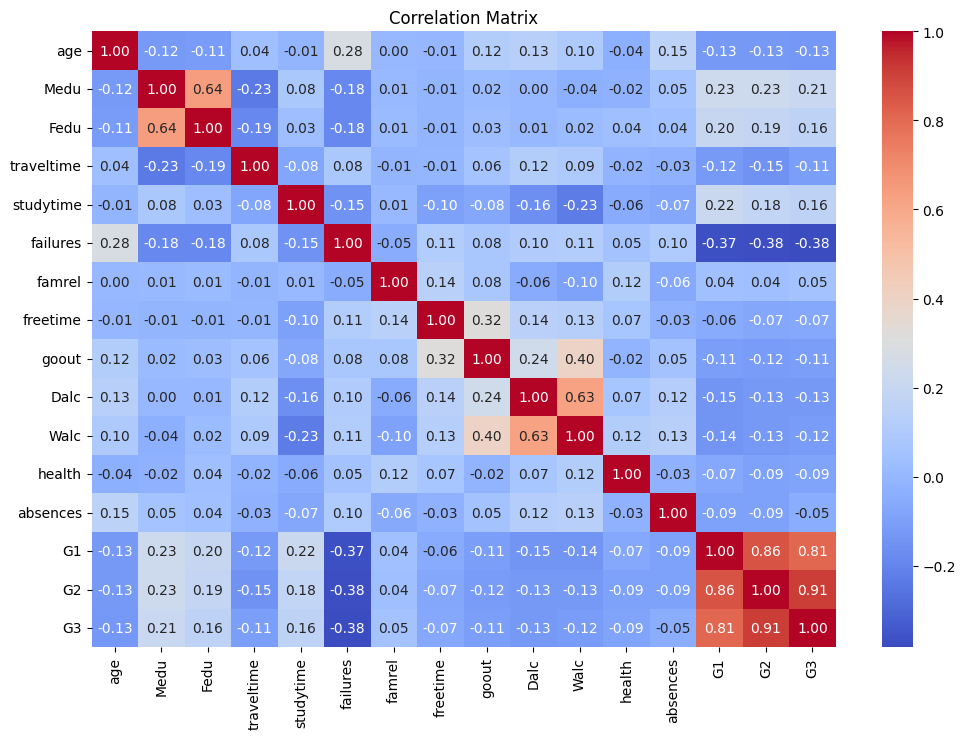

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取数据，确保正确的分隔符
df_combined = pd.read_csv("data/student_combined_cleaned.csv", sep=",", encoding="utf-8")

# 手动选择数值列（只选择实际为数值的列）
numeric_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

# 确保这些列为数值型数据
df_combined[numeric_cols] = df_combined[numeric_cols].apply(pd.to_numeric, errors='coerce')

# 对分类列使用类别数据类型
categorical_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
df_combined[categorical_cols] = df_combined[categorical_cols].astype('category')

# 填充数值列的缺失值（使用中位数填充）
df_combined[numeric_cols] = df_combined[numeric_cols].fillna(df_combined[numeric_cols].median())

# 填充分类列的缺失值（使用最常见的类别填充）
df_combined[categorical_cols] = df_combined[categorical_cols].apply(lambda x: x.fillna(x.mode()[0]))

# 检查是否还有缺失值
print(df_combined.isnull().sum())

# 计算数值列的相关性矩阵
correlation_matrix = df_combined[numeric_cols].corr()

# 绘制相关性热力图
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()